# 05 Ocean and sea ice: `lab_sea`, forward and adjoint

- **Tier:** cluster (one CPU node; the run below used 8 cores)
- **Run time:** about 30 min (measured: 1745 s on a compute node pinned to 8 cores: the forward 5.5 min, the
  adjoint gradient check 23 min, nearly all of it compiling the adjoint program)
- **Peak memory:** about 23 GB (measured: 21.7 GiB, while compiling the adjoint)
- **Experiment:** `verification/lab_sea`: variant `input` (forward, 20 x 16 x 23 points in four tiles of 10 x 8,
  9 steps of 1 h, with `pkg/seaice`, `exf`, `kpp`, `gmredi`) and variant `input_ad` (the adjoint build `code_ad`,
  4 steps, the ECCO cost of `data.ecco`, the control `xx_atemp`)
- **Shows:** the first full ocean + sea-ice model: a forward run checked against `results/output.txt` and maps
  of the sea ice; then the gradient check of the adjoint, compared with TAF's tangent-linear model and with the
  Tapenade adjoint (both 10 digits or more), and TAF's own adjoint, which is off by 1e-4 to 9e-4.

Everything here goes through the API (`mitjax.load`, `exp.run`, `exp.grid`, `exp.grdchk`, `mitjax.compare`).
All runs use `lab_sea`'s own `code/SIZE.h` (four tiles); the cell after the forward run says why the tiling matters.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mitjax
from mitjax import paths

VERIFICATION = paths.UPSTREAM / "verification"


def new_out(name):
    """A new output directory runs/<name>-<n> next to this notebook (mitjax never writes into an existing one)."""
    n = 1
    while Path(f"runs/{name}-{n}").exists():
        n += 1
    return Path(f"runs/{name}-{n}")


def digits(a, b):
    """Agreeing significant digits of two numbers: floor(-log10(|a-b| / max(|a|,|b|))), 16 when equal."""
    if a == b:
        return 16
    return int(np.floor(-np.log10(abs(a - b) / max(abs(a), abs(b)))))

## 1. The forward run

`lab_sea/input` is MITgcm's standard sea-ice test: a coarse (2 degree) Labrador Sea with the dynamic-thermodynamic
sea-ice model (`SEAICE_LSR` for the ice momentum, `SEAICE_GROWTH` for the thermodynamics), bulk forcing from
`pkg/exf`, KPP mixing and GM/Redi. The comparison is `testreport`'s, against the Fortran's
`results/output.txt`, including the sea-ice monitor lines (`aSI`, `hSI`: ice area and thickness).

In [2]:
exp = mitjax.load(VERIFICATION / "lab_sea", variant="input")
cfg = exp.config.cfg
sz = cfg.size
print(f"grid {sz.Nx} x {sz.Ny} x {sz.Nr}, {sz.nSx * sz.nSy} tiles of {sz.sNx} x {sz.sNy}")
print("packages compiled:", ", ".join(cfg.packages))

t0 = time.time()
run = exp.run(out=new_out("05_forward"))
print(f"ran in {time.time() - t0:.0f} s")
rep = mitjax.compare(run, exp.results())
print(rep.summary)

grid 20 x 16 x 23, 4 tiles of 10 x 8
packages compiled: cd_code, debug, diagnostics, exf, generic_advdiff, gmredi, kpp, longstep, mdsio, mnc, mom_common, mom_fluxform, mom_vecinv, monitor, ptracers, rw, salt_plume, seaice, cal


ran in 337 s
Y Y Y Y>16<16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 22 16 16 16 22 16 16 16  .  .  .  .  .  .  .  .  .  .  .  . pass  lab_sea


In [3]:
MIN_DIGITS = 10                                    # testreport's MATCH_CRIT
assert rep.verdict == "pass", rep.summary
assert min(v.digits for v in rep.run.variables) >= MIN_DIGITS

**Tiling matters here, in the Fortran too.** `SEAICE_LSR` solves its lines within a tile: the line ends read the
neighbour tile's previous iterate from the halo (`seaice_lsr.F:2001-2002`, one exchange per sweep, `:987`), and
the sweeps stop at `LSR_ERROR = 1.E-4` (`input/data.seaice:29`, test at `seaice_lsr.F:955`). Another tiling
therefore stops at another, equally converged, iterate. Run on one 20 x 16 tile instead of four, `lab_sea/input`
agrees with `results/` to only 2-9 digits (sea-ice velocity changes by up to 4e-4 m/s after 9 steps), and a
gfortran build with that one-tile `SIZE.h` gives exactly the same numbers as mitjax. A tighter `LSR_ERROR` makes
the difference smaller. (The tiling also changes what MONITOR prints: the `dynstat_sst/sss` lines appear only
with `nSx = nSy = 1`, `monitor.F:122-131`.)

### Sea-ice maps

`run.fields` holds the final state by name: the ocean's (`theta`, `uVel`, ...) and, with `pkg/seaice`, the sea
ice's by its `SEAICE.h` names (`AREA`, `HEFF`, `UICE`, `VICE`, ...), in mitjax's storage layout (one array per
tile, with halos). `run.global_field(name)` puts the four tiles together as MITgcm numbers them (along x first) and
drops the halos; `exp.grid()` gives the grid (`GRID.h` arrays by Fortran name) the same way, without a run.

The ice velocity lives on the cell faces (C grid: `UICE` on the western, `VICE` on the southern face); for the map
it is averaged to the cell centres. It is shown only where there is ice (`AREA > 0`): the line solver also returns
a velocity in open water, which has no meaning there.

{'AREA': (16, 20), 'HEFF': (16, 20), 'UICE': (16, 20), 'VICE': (16, 20)}


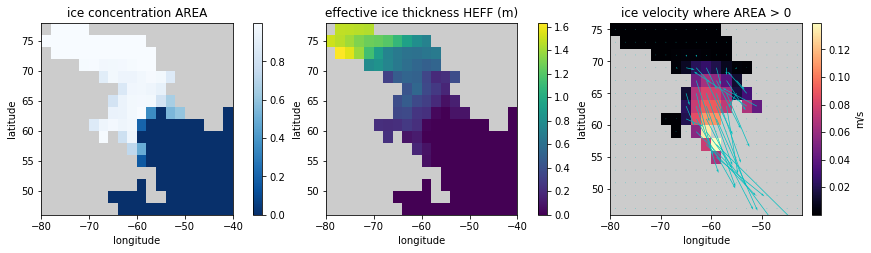

ice-covered cells: 69 of 137 wet cells shown in the velocity panel


In [4]:
ice = {n: run.global_field(n) for n in ("AREA", "HEFF", "UICE", "VICE")}     # [j, i]
print({n: a.shape for n, a in ice.items()})
grid = exp.grid()
lon, lat = grid.global_field("xC") - 360, grid.global_field("yC")    # cell centres (degrees east, north)
wet = grid.global_field("maskC")[0] != 0           # ocean at the surface

uc = 0.5 * (ice["UICE"][:, :-1] + ice["UICE"][:, 1:])     # at the centres of columns 1 .. Nx-1
vc = 0.5 * (ice["VICE"][:-1, :] + ice["VICE"][1:, :])     # at the centres of rows 1 .. Ny-1
uc, vc = uc[:-1, :], vc[:, :-1]                    # both on cells [0:Ny-1, 0:Nx-1]
iced = (wet & (ice["AREA"] > 0))[:-1, :-1]         # no ice speed in open water (AREA = 0)
speed = np.hypot(uc, vc)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4), dpi=72, constrained_layout=True)
for a, f, t, cm in ((ax[0], ice["AREA"], "ice concentration AREA", "Blues_r"),
                    (ax[1], ice["HEFF"], "effective ice thickness HEFF (m)", "viridis")):
    pc = a.pcolormesh(lon, lat, np.where(wet, f, np.nan), cmap=cm, shading="nearest")
    fig.colorbar(pc, ax=a)
    a.set_title(t)
pc = ax[2].pcolormesh(lon[:-1, :-1], lat[:-1, :-1], np.where(iced, speed, np.nan), cmap="magma", shading="nearest")
fig.colorbar(pc, ax=ax[2], label="m/s")
ax[2].quiver(lon[:-1, :-1], lat[:-1, :-1], np.where(iced, uc, 0), np.where(iced, vc, 0), color="c")
ax[2].set_title("ice velocity where AREA > 0")
for a in ax:
    a.set_xlabel("longitude"); a.set_ylabel("latitude"); a.set_facecolor("0.8")
plt.show()
print(f"ice-covered cells: {int(iced.sum())} of {int(wet[:-1, :-1].sum())} wet cells shown in the velocity panel")

In [5]:
assert all(np.isfinite(ice[n]).all() for n in ice)
assert 0 <= ice["AREA"].min() and ice["AREA"].max() <= 1 and ice["AREA"].max() > 0
assert ice["HEFF"].min() >= 0 and ice["HEFF"].max() > 0
assert iced.any() and np.isfinite(speed[iced]).all()

## 2. The adjoint: the gradient check

`lab_sea/input_ad` runs the adjoint build `code_ad` for 4 steps. Its cost is the ECCO-style misfit of
`data.ecco`, its controls are set in `data.ctrl`, and `data.grdchk` checks the gradient with respect to the
2-m air temperature control `xx_atemp` at five points. `ad.grdchk` does what `pkg/grdchk`'s `GRDCHK_MAIN` does:
the adjoint gradient at those points and the centred finite differences with `grdchk_eps = 1e-3`, printed as
`output_adm.txt` prints them.

**The sea-ice solver.** The ice momentum equations are solved iteratively (`SEAICE_LSR`, line relaxation). In
general mitjax never differentiates through solver iterations; it uses the derivative of the converged solution
instead. Here the build defines `SEAICE_LSR_ADJOINT_ITER`, which tells TAF to record every executed LSR iteration
and differentiate through them. mitjax does the same here (the one exception to its rule): the iteration runs as a
fixed-length loop of `SOLV_MAX_FIXED = 500` sweeps that stop changing the solution where the Fortran's
convergence test stops the loop, so the forward is bit for bit the plain loop, and JAX differentiates the sweeps
that were executed. The API selects this from the build's CPP options; nothing to set. (A build without
`SEAICE_LSR_ADJOINT_ITER`, such as notebook 06's, gets the same derivative of the executed sweeps by the API's
default, `lsr_derivative=None` (plan decisions 14 and 17); there `lsr_derivative="run"` keeps the build's own
choice, which leaves the solver without a derivative, and the gradient stops with an error that says so.)

The adjoint program is large: compiling it takes most of this section's time and most of the memory.

In [6]:
import gc

import jax

jax.clear_caches(); gc.collect()                   # free the forward's compiled programs before the large adjoint
ad = mitjax.load(VERIFICATION / "lab_sea", variant="input_ad")
t0 = time.time()
chk = ad.grdchk(out=new_out("05_grdchk"))
print(f"{time.time() - t0:.0f} s")
start = next(n for n, ln in enumerate(chk.lines) if "Gradient check results" in ln)
print("\n".join(chk.lines[start - 1:]))

1382 s
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) // Gradient check results  >>> START <<<
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) 
(PID.TID 0000.0001)  EPS = 1.000000E-03 ; grdchk CTRL var/file name: "xx_atemp"
(PID.TID 0000.0001) 
(PID.TID 0000.0001) grdchk output h.p:  Id Itile Jtile LAYER   bi   bj   X(Id)           X(Id)+/-EPS
(PID.TID 0000.0001) grdchk output h.c:  Id  FC                   FC1                  FC2
(PID.TID 0000.0001) grdchk output h.g:  Id     FC1-FC2/(2*EPS)      ADJ GRAD(FC)         1-FDGRD/ADGRD
(PID.TID 0000.0001) 
(PID.TID 0000.0001) grdchk output (p):   1     6     8     1    1    1   0.000000000E+00 -1.000000000E-03
(PID.TID 0000.0001) grdchk output (c):   1  7.2364944579778E+03  7.2364944591623E+03  7.2364944587933E+03
(PID.TID 0000.0001) grdchk output (g):   1     1.8450737115927E-04  1.8450795189492E-04  3.1474830233247E-06
(PID.TID 0000.00

### Compared with three references

The `results/` directory of `lab_sea` holds three derivatives of the same cost at the same five points, all
computed by Fortran builds of the same code:

- `output_adm.txt`: TAF's adjoint (what `testreport` compares an adjoint run with);
- `output_tlm.txt.gz`: TAF's tangent-linear model (forward-mode derivative);
- `output_tap_adj.txt`: the Tapenade adjoint.

A correct adjoint equals the tangent-linear derivative to round-off, so all three should agree.

In [7]:
R = ad.results()


def ref_values(path, key):
    import gzip
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt") as fh:
        return [float(ln.split("=")[1]) for ln in fh if key in ln]


ours = [c["adjoint_gradient"] for c in chk.checks]
fd = [c["gfd"] for c in chk.checks]
tlm = ref_values(R.output_tlm, "TLM  tangent-lin_grad")
tap = ref_values(ad.exp_dir / "results" / "output_tap_adj.txt", "ADM  adjoint_gradient")
adm = ref_values(R.output_adm, "ADM  adjoint_gradient")
print(" i  mitjax adjoint          digits vs: TAF TLM  Tapenade  TAF adjoint   TAF adjoint / TAF TLM - 1")
for c, g, a, b, t in zip(chk.checks, ours, tlm, tap, adm):
    print(f"{c['i']:2d}  {g:22.14E}  {digits(g, a):17d} {digits(g, b):9d} {digits(g, t):12d}   {t / a - 1:12.2E}")
print("our finite differences, 1 - FD/adjoint:", ", ".join(f"{1 - f / g:.1E}" for f, g in zip(fd, ours)))

 i  mitjax adjoint          digits vs: TAF TLM  Tapenade  TAF adjoint   TAF adjoint / TAF TLM - 1
 6    1.84507951894917E-04                 12        12            4      -9.72E-05
 7    1.78840653676585E-04                 12        12            3      -1.07E-04
 8    2.32137879127995E-04                 12        13            3      -4.88E-04
 9    2.98245428792268E-04                 12        13            3      -8.81E-04
10    3.75155817043323E-04                 12        12            3      -7.57E-04
our finite differences, 1 - FD/adjoint: 3.1E-06, -3.2E-06, 1.2E-06, -3.6E-06, -7.7E-07


In [8]:
MIN_GRAD_DIGITS = 10                               # testreport's MATCH_CRIT for admGrd
assert len(ours) == len(tlm) == len(tap) == len(adm) == 5
assert min(digits(g, a) for g, a in zip(ours, tlm)) >= MIN_GRAD_DIGITS
assert min(digits(g, b) for g, b in zip(ours, tap)) >= MIN_GRAD_DIGITS
assert all(np.isfinite(ours)) and all(abs(1 - f / g) < 1e-4 for f, g in zip(fd, ours))
# TAF's adjoint against TAF's own tangent-linear model (two Fortran results, nothing computed here): 1e-4 .. 1e-3
assert all(1e-5 < abs(t / a - 1) < 1e-2 for t, a in zip(adm, tlm))

mitjax's adjoint agrees with TAF's tangent-linear model and with the Tapenade adjoint to 12-13 digits. TAF's
adjoint differs from all of them, and from the finite differences, by 1e-4 to 9e-4 (3-4 digits); testreport
against `output_adm.txt` therefore reports only 3 digits for `admGrd`:

In [9]:
rep_adm = mitjax.compare(chk, R)
print(rep_adm.summary)
print({v.name: v.digits for v in rep_adm.run.variables})

Y Y Y Y 16> 3<16 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- FAIL  lab_sea
{'admCst': 16, 'admGrd': 3, 'admFwd': 16, 'Tmn': 99, 'Tmx': 99, 'Tav': 99, 'Tsd': 99, 'Smn': 99, 'Smx': 99, 'Sav': 99, 'Ssd': 99, 'Umn': 99, 'Umx': 99, 'Uav': 99, 'Usd': 99, 'Vmn': 99, 'Vmx': 99, 'Vav': 99, 'Vsd': 99}


**Why TAF's adjoint is off.** TAF's adjoint of this run disagrees with TAF's own tangent-linear model and with the
Tapenade adjoint of the same code, and comparing the adjoint variables step by step places the departure in the
reverse of the sea-ice dynamics (`SEAICE_LSR`) in the last time step. We reported it as
[MITgcm issue #1041](https://github.com/MITgcm/MITgcm/issues/1041); mitjax uses the tangent-linear model and the
Tapenade adjoint as this experiment's reference.

## Next

- [06_adjoint_modes_cs32x15](06_adjoint_modes_cs32x15.ipynb): TAF's adjoint-mode approximations
  (`data.autodiff`) and how mitjax follows or drops them.
- [07_parallel](07_parallel.ipynb): the same programs split over several devices.